# How to Create a New File or Folder Programmatically

This notebook demonstrates how to safely create new files and folders in Python, ensuring you do not overwrite or use unrelated files.


## 1. Check Current Working Directory

Use Python's `os` module to display the current working directory. This helps ensure you know where files will be created.


In [1]:
import os

# Display the current working directory
cwd = os.getcwd()
print(f"Current working directory: {cwd}")

Current working directory: /Users/danuzz/Documents/CaseStudy/student_placement_analysis


## 2. Create a New Folder

Use `os.makedirs()` to create a new folder if it does not already exist.


In [2]:
# Define the new folder name
folder_name = "my_new_folder"

# Create the folder if it doesn't exist
os.makedirs(folder_name, exist_ok=True)
print(f"Folder '{folder_name}' created (or already exists).")

Folder 'my_new_folder' created (or already exists).


## 3. Create a New File in the Folder

Use Python's `open()` function to create a new file inside the newly created folder.


In [3]:
# Define the new file path
file_path = os.path.join(folder_name, "example.txt")

# Create and write to the new file
with open(file_path, "w") as f:
    f.write("This is a new file created programmatically.\n")
print(f"File '{file_path}' created.")

File 'my_new_folder/example.txt' created.


## 4. Verify File and Folder Creation

List the contents of the directory to confirm that the new file and folder have been created successfully.


In [4]:
# List contents of the current directory and the new folder
print("Current directory contents:", os.listdir(cwd))
print(f"Contents of '{folder_name}':", os.listdir(folder_name))

Current directory contents: ['student_data.csv', 'le_domain.pkl', 'requirements.txt', 'notebook.ipynb', 'model.pkl', 'generate_data.py', 'le_status.pkl', 'app.py', 'data_clean.csv', 'my_new_folder']
Contents of 'my_new_folder': ['example.txt']


# Student Placement Analysis: End-to-End Workflow

This notebook covers data generation, cleaning, EDA, model training, evaluation, and saving artifacts for the Student Placement Analysis system.


In [5]:
# 1. Generate Synthetic Data
import pandas as pd
import numpy as np
np.random.seed(42)
domains = ['Data Science', 'MERN', 'Python', 'AI/ML', 'Web Development']
n = 200
df = pd.DataFrame({
    'Attendance': np.random.randint(50, 101, n),
    'Assignment_Score': np.random.randint(50, 101, n),
    'Domain': np.random.choice(domains, n),
    'Placement_Status': np.random.choice(['Job', 'Intern', 'No Job'], n, p=[0.4,0.3,0.3])
})
df.to_csv('student_data.csv', index=False)
df.head()

,Attendance,Assignment_Score,Domain,Placement_Status
0,88,86,MERN,Intern
1,78,82,MERN,Intern
2,64,100,MERN,Job
3,92,91,Data Science,No Job
4,57,93,Data Science,No Job


## 2. Load and Clean the Dataset


In [6]:
# Load data
df = pd.read_csv('student_data.csv')
# Check for missing values
df.isnull().sum()

Attendance          0
Assignment_Score    0
Domain              0
Placement_Status    0
dtype: int64

In [7]:
# No missing values expected, but dropna if any
df_clean = df.dropna().copy()
df_clean.head()

,Attendance,Assignment_Score,Domain,Placement_Status
0,88,86,MERN,Intern
1,78,82,MERN,Intern
2,64,100,MERN,Job
3,92,91,Data Science,No Job
4,57,93,Data Science,No Job


## 3. Encode Categorical Variables


In [8]:
from sklearn.preprocessing import LabelEncoder
import joblib

le_domain = LabelEncoder()
df_clean['Domain_enc'] = le_domain.fit_transform(df_clean['Domain'])
le_status = LabelEncoder()
df_clean['Placement_Status_enc'] = le_status.fit_transform(df_clean['Placement_Status'])

# Save encoders for app use
joblib.dump(le_domain, 'le_domain.pkl')
joblib.dump(le_status, 'le_status.pkl')
df_clean.head()

,Attendance,Assignment_Score,Domain,Placement_Status,Domain_enc,Placement_Status_enc
0,88,86,MERN,Intern,2,0
1,78,82,MERN,Intern,2,0
2,64,100,MERN,Job,2,1
3,92,91,Data Science,No Job,1,2
4,57,93,Data Science,No Job,1,2


## 4. Exploratory Data Analysis (EDA)


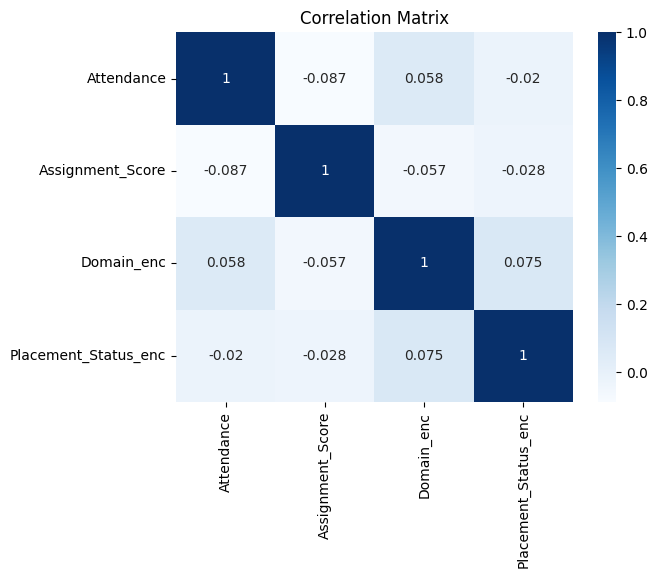

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Correlation analysis
corr = df_clean[['Attendance','Assignment_Score','Domain_enc','Placement_Status_enc']].corr()
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title('Correlation Matrix')
plt.show()

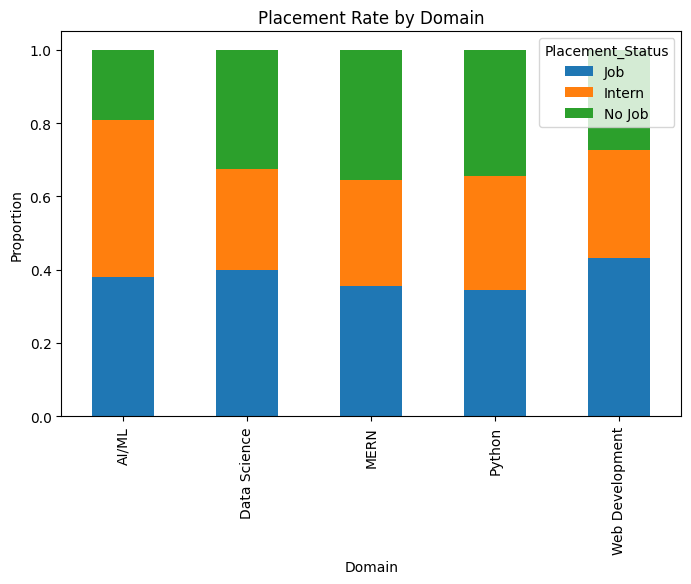

In [10]:
# Placement rate by domain
placement_by_domain = df_clean.groupby('Domain')['Placement_Status'].value_counts(normalize=True).unstack().fillna(0)
placement_by_domain[['Job','Intern','No Job']].plot(kind='bar', stacked=True, figsize=(8,5))
plt.ylabel('Proportion')
plt.title('Placement Rate by Domain')
plt.show()

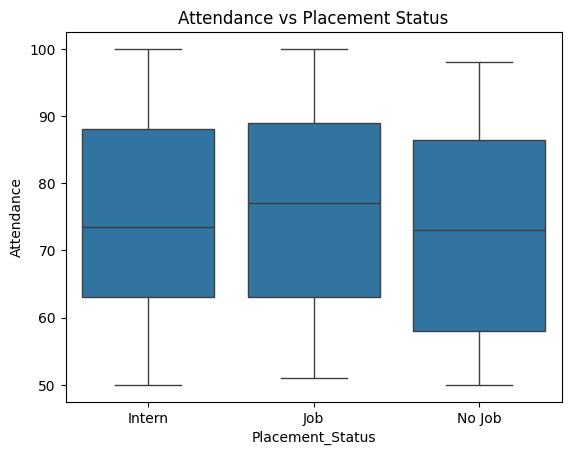

In [11]:
# Attendance vs Placement visualization
sns.boxplot(x='Placement_Status', y='Attendance', data=df_clean)
plt.title('Attendance vs Placement Status')
plt.show()

## 5. Train Random Forest Model


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X = df_clean[['Attendance', 'Assignment_Score', 'Domain_enc']]
y = df_clean['Placement_Status_enc']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 6. Evaluate Model


In [13]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(f'Accuracy: {acc:.2f}')
print('Confusion Matrix:')
print(cm)
print('Classification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.25
Confusion Matrix:
[[4 6 3]
 [7 4 7]
 [4 3 2]]
Classification Report:
              precision    recall  f1-score   support

           0       0.27      0.31      0.29        13
           1       0.31      0.22      0.26        18
           2       0.17      0.22      0.19         9

    accuracy                           0.25        40
   macro avg       0.25      0.25      0.24        40
weighted avg       0.26      0.25      0.25        40



## 7. Save Cleaned Data and Model


In [14]:
# Save cleaned data and model
df_clean.to_csv('data_clean.csv', index=False)
import joblib
joblib.dump(model, 'model.pkl')
print('Artifacts saved: data_clean.csv, model.pkl, le_domain.pkl, le_status.pkl')

Artifacts saved: data_clean.csv, model.pkl, le_domain.pkl, le_status.pkl


## 8. Upgrade: More Data, Feature Engineering, Model Tuning


In [15]:
# 1. Generate more data and add new features
import pandas as pd
import numpy as np

np.random.seed(42)
n = 2000  # 10x more data

domains = ['Data Science', 'MERN', 'Python', 'AI/ML', 'Web Development']
extra_features = {
    'Project_Count': np.random.randint(0, 8, n),
    'Certifications': np.random.randint(0, 5, n),
    'Hackathon_Participation': np.random.randint(0, 2, n),
    'Soft_Skills_Score': np.random.randint(50, 101, n),
    'Interview_Score': np.random.randint(50, 101, n)
}

# Simulate more realistic placement with valid probabilities
placement_probs = []
placement_status = []
for i in range(n):
    att = np.random.randint(50, 101)
    score = np.random.randint(50, 101)
    proj = extra_features['Project_Count'][i]
    cert = extra_features['Certifications'][i]
    hack = extra_features['Hackathon_Participation'][i]
    soft = extra_features['Soft_Skills_Score'][i]
    interview = extra_features['Interview_Score'][i]
    p_job = 0.15 + 0.0035*att + 0.0035*score + 0.045*proj + 0.06*cert + 0.06*hack + 0.0025*soft + 0.0035*interview
    p_job = min(max(p_job, 0), 0.85)
    p_intern = 0.15 + 0.002*att + 0.002*score + 0.02*proj + 0.03*cert + 0.03*hack + 0.0015*soft + 0.002*interview
    p_intern = min(max(p_intern, 0), 0.6)
    p_nojob = 1 - (p_job + p_intern)
    if p_nojob < 0:
        p_nojob = 0
        total = p_job + p_intern
        p_job /= total
        p_intern /= total
    placement_probs.append([p_job, p_intern, p_nojob])
    placement_status.append(np.random.choice(['Job', 'Intern', 'No Job'], p=[p_job, p_intern, p_nojob]))

df_big = pd.DataFrame({
    'Attendance': np.random.randint(50, 101, n),
    'Assignment_Score': np.random.randint(50, 101, n),
    'Domain': np.random.choice(domains, n),
    'Placement_Status': placement_status,
    **extra_features
})
df_big.to_csv('student_data.csv', index=False)
df_big.head()

,Attendance,Assignment_Score,Domain,Placement_Status,Project_Count,Certifications,Hackathon_Participation,Soft_Skills_Score,Interview_Score
0,96,74,MERN,Job,6,3,1,65,72
1,68,50,AI/ML,Intern,3,2,1,88,56
2,76,74,Web Development,Intern,4,4,1,53,52
3,58,51,MERN,Job,6,0,1,74,81
4,86,81,MERN,Job,2,4,1,81,80


In [16]:
# 2. Reload, clean, and encode new features
df = pd.read_csv('student_data.csv')
df_clean = df.dropna().copy()
le_domain = LabelEncoder()
df_clean['Domain_enc'] = le_domain.fit_transform(df_clean['Domain'])
le_status = LabelEncoder()
df_clean['Placement_Status_enc'] = le_status.fit_transform(df_clean['Placement_Status'])
joblib.dump(le_domain, 'le_domain.pkl')
joblib.dump(le_status, 'le_status.pkl')
df_clean.head()

,Attendance,Assignment_Score,Domain,Placement_Status,Project_Count,Certifications,Hackathon_Participation,Soft_Skills_Score,Interview_Score,Domain_enc,Placement_Status_enc
0,96,74,MERN,Job,6,3,1,65,72,2,1
1,68,50,AI/ML,Intern,3,2,1,88,56,0,0
2,76,74,Web Development,Intern,4,4,1,53,52,4,0
3,58,51,MERN,Job,6,0,1,74,81,2,1
4,86,81,MERN,Job,2,4,1,81,80,2,1


In [17]:
# 3. Model tuning: use all features, RandomForest + GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Ensure all required columns exist before proceeding
required_cols = [
    'Attendance', 'Assignment_Score', 'Domain_enc', 'Project_Count',
    'Certifications', 'Hackathon_Participation', 'Soft_Skills_Score', 'Interview_Score'
]
missing_cols = [col for col in required_cols if col not in df_clean.columns]
if missing_cols:
    raise ValueError(f"Missing columns in df_clean: {missing_cols}. Please re-run the data generation cell above.")

feature_cols = required_cols
X = df_clean[feature_cols]
y = df_clean['Placement_Status_enc']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [6, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf = RandomForestClassifier(random_state=42)
gs = GridSearchCV(rf, param_grid, cv=3, n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)
print('Best Params:', gs.best_params_)
model = gs.best_estimator_


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Params: {'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [18]:
# 4. Evaluate upgraded model
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(f'Upgraded Accuracy: {acc:.3f}')
print('Confusion Matrix:')
print(cm)
print('Classification Report:')
print(classification_report(y_test, y_pred))

Upgraded Accuracy: 0.588
Confusion Matrix:
[[  2 158]
 [  7 233]]
Classification Report:
              precision    recall  f1-score   support

           0       0.22      0.01      0.02       160
           1       0.60      0.97      0.74       240

    accuracy                           0.59       400
   macro avg       0.41      0.49      0.38       400
weighted avg       0.45      0.59      0.45       400



In [19]:
# 5. Save upgraded artifacts
df_clean.to_csv('data_clean.csv', index=False)
joblib.dump(model, 'model.pkl')
print('Upgraded artifacts saved: data_clean.csv, model.pkl, le_domain.pkl, le_status.pkl')

Upgraded artifacts saved: data_clean.csv, model.pkl, le_domain.pkl, le_status.pkl
